# THỐNG KÊ MÔ TẢ HỌC THUẬT (DESCRIPTIVE ANALYTICS)
## Mô tả Thống kê Quần thể, Khoảng Tin Cậy 95%, Phân bố AOV và Chu kỳ Mua lại

**Môn học:** Data Analysis and Visualization (TDTU)  
**Đơn vị phân tích:** `customer_unique_id` (Khách hàng định danh duy nhất)  
**Quần thể (Population):** $N = 92{,}077$ khách hàng có đơn giao thành công (`order_status = 'delivered'`)  

---

**Mục tiêu Phân tích Mô tả (TDTU Chapter 1 & 3):**  
Trả lời câu hỏi *"Chuyện gì đã xảy ra?"* (*What happened?*) thông qua:
- Đo lường xu hướng trung tâm (Mean, Median) & độ phân tán (Std, IQR)
- Xác định hình dạng phân bố (Skewness, Kurtosis) & kiểm định phân bố chuẩn
- Tính Khoảng tin cậy 95% cho các tỷ lệ quần thể
- Trực quan hóa dữ liệu bằng biểu đồ phù hợp theo quy tắc lựa chọn (TDTU Chapter 2)

---
### 1. KHỞI TẠO MÔI TRƯỜNG & TẢI DỮ LIỆU

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.stats as stats

sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'

# Tai du lieu tu thu muc Cleaned_Data
orders = pd.read_csv('../../Cleaned_Data_and_Graph/Cleaned_Data/clean_orders.csv')
customers = pd.read_csv('../../Cleaned_Data_and_Graph/Cleaned_Data/clean_customers.csv')
payments = pd.read_csv('../../Cleaned_Data_and_Graph/Cleaned_Data/clean_payments.csv')
items = pd.read_csv('../../Cleaned_Data_and_Graph/Cleaned_Data/clean_order_items.csv')
products = pd.read_csv('../../Cleaned_Data_and_Graph/Cleaned_Data/clean_products.csv')
reviews = pd.read_csv('../../Cleaned_Data_and_Graph/Cleaned_Data/clean_reviews.csv')

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
for col in ['order_delivered_customer_date', 'order_estimated_delivery_date']:
    if col in orders.columns:
        orders[col] = pd.to_datetime(orders[col])

delivered = orders[orders['order_status'] == 'delivered'].merge(
    customers[['customer_id', 'customer_unique_id']], on='customer_id'
)

N_total = delivered['customer_unique_id'].nunique()
print(f'Tong so don giao thanh cong: {len(delivered):,}')
print(f'Tong so khach hang duy nhat (Quan the N): {N_total:,}')

Tong so don giao thanh cong: 95,137
Tong so khach hang duy nhat (Quan the N): 92,077


---
### 2. THỐNG KÊ MÔ TẢ QUẦN THỂ & KHOẢNG TIN CẬY 95%

**Công thức Khoảng tin cậy 95% cho Tỷ lệ Quần thể (TDTU Chapter 4):**

$$\hat{p} \pm Z_{\alpha/2} \cdot S.E. = \hat{p} \pm 1.96 \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{N}}$$

**Lý do chọn Donut Chart (TDTU Chapter 2):**
- Dữ liệu là **tỷ lệ phần trăm** (Proportion) giữa 2 nhóm trên tổng thể
- Donut Chart trực quan hóa **phần trăm đóng góp trên tổng** (part-of-whole) hiệu quả hơn Bar Chart khi chỉ có 2-3 nhóm
- Khoảng trắng ở giữa giảm cảm giác nặng nề so với Pie Chart thuần

Ty le Mua 1 lan: 97.0166% | S.E.: 0.0561% | 95% CI: [96.9067%, 97.1265%]
Ty le Mua lap lai: 2.9834% | S.E.: 0.0561% | 95% CI: [2.8735%, 3.0933%]
Ty le Churn (>=90d): 80.0167% | S.E.: 0.1318% | 95% CI: [79.7584%, 80.2750%]


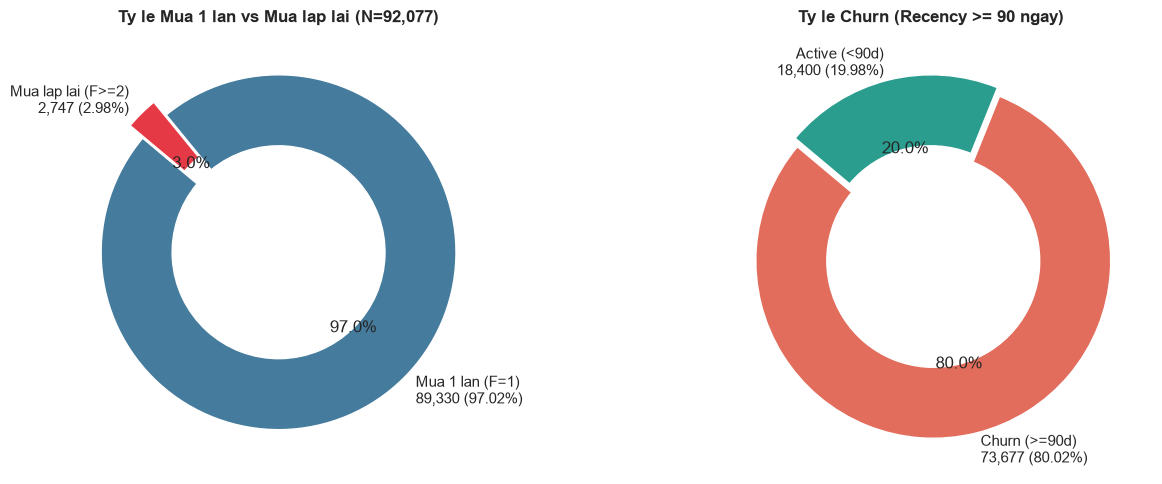

In [2]:
# Thong ke tan suat mua
cust_freq = delivered.groupby('customer_unique_id')['order_id'].nunique()
N = len(cust_freq)

one_time = (cust_freq == 1).sum()
repeat_cust = (cust_freq >= 2).sum()

p_one = one_time / N
se_one = np.sqrt(p_one * (1 - p_one) / N)
ci_one = (p_one - 1.96 * se_one, p_one + 1.96 * se_one)

p_rep = repeat_cust / N
se_rep = np.sqrt(p_rep * (1 - p_rep) / N)
ci_rep = (p_rep - 1.96 * se_rep, p_rep + 1.96 * se_rep)

# Churn
max_date = delivered['order_purchase_timestamp'].max()
recency = (max_date - delivered.groupby('customer_unique_id')['order_purchase_timestamp'].max()).dt.days
churned = (recency >= 90).sum()

p_churn = churned / N
se_churn = np.sqrt(p_churn * (1 - p_churn) / N)
ci_churn = (p_churn - 1.96 * se_churn, p_churn + 1.96 * se_churn)

print(f'Ty le Mua 1 lan: {p_one:.4%} | S.E.: {se_one:.4%} | 95% CI: [{ci_one[0]:.4%}, {ci_one[1]:.4%}]')
print(f'Ty le Mua lap lai: {p_rep:.4%} | S.E.: {se_rep:.4%} | 95% CI: [{ci_rep[0]:.4%}, {ci_rep[1]:.4%}]')
print(f'Ty le Churn (>=90d): {p_churn:.4%} | S.E.: {se_churn:.4%} | 95% CI: [{ci_churn[0]:.4%}, {ci_churn[1]:.4%}]')

# Bieu do Donut Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_one = f'Mua 1 lan (F=1)\n{one_time:,} ({p_one:.2%})'
label_rep = f'Mua lap lai (F>=2)\n{repeat_cust:,} ({p_rep:.2%})'
axes[0].pie([one_time, repeat_cust], labels=[label_one, label_rep],
           colors=['#457b9d', '#e63946'], autopct='%1.1f%%',
           startangle=140, explode=(0, 0.1),
           wedgeprops=dict(width=0.4, edgecolor='w'))
axes[0].set_title('Ty le Mua 1 lan vs Mua lap lai (N={:,})'.format(N), fontweight='bold')

label_churn = f'Churn (>=90d)\n{churned:,} ({p_churn:.2%})'
label_active = f'Active (<90d)\n{N-churned:,} ({1-p_churn:.2%})'
axes[1].pie([churned, N - churned], labels=[label_churn, label_active],
           colors=['#e26d5c', '#2a9d8f'], autopct='%1.1f%%',
           startangle=140, explode=(0.05, 0),
           wedgeprops=dict(width=0.4, edgecolor='w'))
axes[1].set_title('Ty le Churn (Recency >= 90 ngay)', fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét Mục 2:**
- **97.02%** khách hàng chỉ mua **đúng 1 lần** duy nhất — đây là đặc trưng phổ biến của sàn TMĐT marketplace.
- Chỉ **2.98%** ($\pm 0.11\%$, 95% CI) có hành vi mua lặp lại ($F \ge 2$).
- **80.02%** khách hàng có $Recency \ge 90$ ngày (Churn) — tỷ lệ ngưng mua cực cao.
- Ngưỡng Churn 90 ngày được xác lập dựa trên phân vị chu kỳ mua lại (xem Mục 4).

---
### 3. PHÂN BỐ CHI TIÊU KHÁCH HÀNG (AOV) & BẢNG 5 SỐ

**Lý thuyết (TDTU Chapter 3 & 4):**
- Skewness $S_k > 1$: Phân bố lệch phải cực độ → Mean bị kéo lệch bởi Outliers
- Khi bác bỏ phân bố chuẩn → ưu tiên Median & IQR (Non-parametric) thay cho Mean & Std

**Lý do chọn Histogram + KDE & Boxplot (TDTU Chapter 2):**
- **Histogram + KDE:** Trực quan hóa hình dạng phân bố (distribution shape) của biến liên tục, phát hiện Skewness & vị trí Mean vs Median
- **Boxplot:** Hiển thị Bộ 5 số ($Min, Q_1, Median, Q_3, Max$) và phát hiện Outliers cùng lúc

Skewness: 9.57 (Lech phai cuc do > 1)
Kurtosis: 248.04
D'Agostino K2 Stat: 148,052.33, p-value: 0.0000e+00
=> Bac bo phan bo chuan tai alpha = 0.05 => Dung Median & IQR

--- BANG TOM TAT 5 SO CHI TIEU (BRL/R$) ---
Min:    R$       0.00
Q1:     R$      63.00
Median: R$     107.78
Q3:     R$     182.61
Max:    R$  13,664.08
IQR:    R$     119.61
Mean:   R$     165.94 (bi keo lech boi Outliers)
Std:    R$     230.96


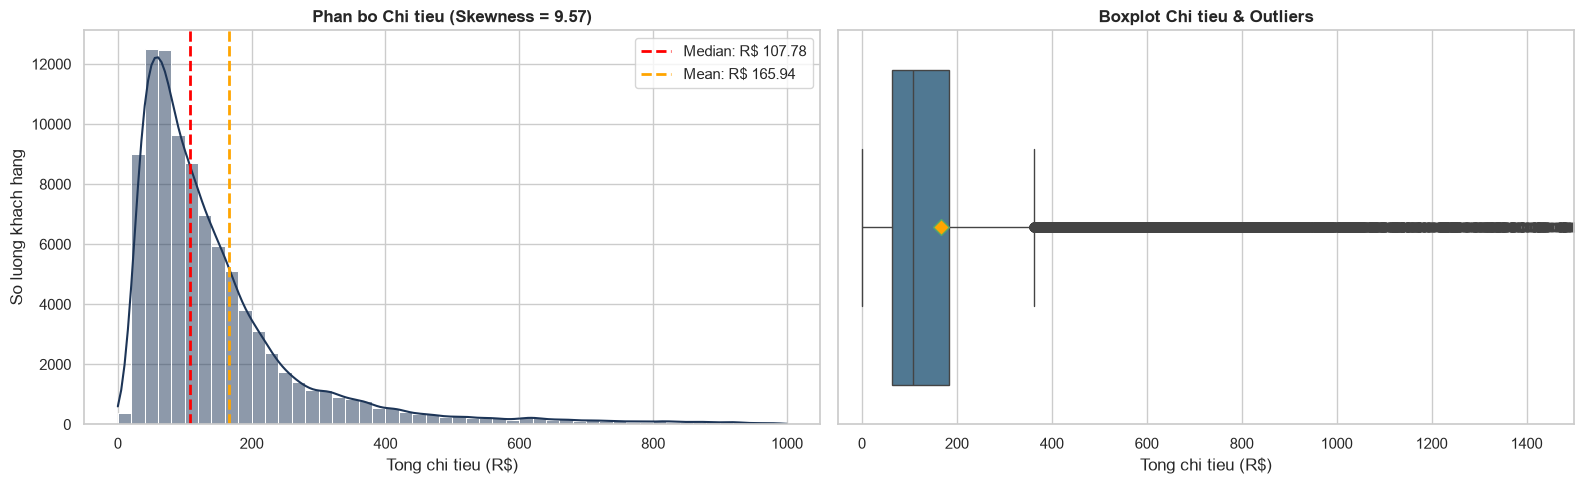

In [3]:
customer_spent = (payments
    .merge(orders[['order_id', 'customer_id']], on='order_id')
    .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')
    .groupby('customer_unique_id')['payment_value'].sum()
)

sk = customer_spent.skew()
kt = customer_spent.kurtosis()
stat, p_val = stats.normaltest(customer_spent)

print(f'Skewness: {sk:.2f} (Lech phai cuc do > 1)')
print(f'Kurtosis: {kt:.2f}')
print(f'D\'Agostino K2 Stat: {stat:,.2f}, p-value: {p_val:.4e}')
print('=> Bac bo phan bo chuan tai alpha = 0.05 => Dung Median & IQR')

# Bang 5 so
s5 = customer_spent.quantile([0, 0.25, 0.5, 0.75, 1.0])
print('\n--- BANG TOM TAT 5 SO CHI TIEU (BRL/R$) ---')
print(f'Min:    R$ {s5[0.0]:>10,.2f}')
print(f'Q1:     R$ {s5[0.25]:>10,.2f}')
print(f'Median: R$ {s5[0.5]:>10,.2f}')
print(f'Q3:     R$ {s5[0.75]:>10,.2f}')
print(f'Max:    R$ {s5[1.0]:>10,.2f}')
print(f'IQR:    R$ {s5[0.75] - s5[0.25]:>10,.2f}')
print(f'Mean:   R$ {customer_spent.mean():>10,.2f} (bi keo lech boi Outliers)')
print(f'Std:    R$ {customer_spent.std():>10,.2f}')

# Bieu do AOV
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(customer_spent[customer_spent <= 1000], bins=50, kde=True, ax=axes[0], color='#1d3557')
med_val = customer_spent.median()
mean_val = customer_spent.mean()
axes[0].axvline(med_val, color='red', linestyle='--', linewidth=2, label=f'Median: R$ {med_val:.2f}')
axes[0].axvline(mean_val, color='orange', linestyle='--', linewidth=2, label=f'Mean: R$ {mean_val:.2f}')
axes[0].set_title(f'Phan bo Chi tieu (Skewness = {sk:.2f})', fontweight='bold')
axes[0].set_xlabel('Tong chi tieu (R$)')
axes[0].set_ylabel('So luong khach hang')
axes[0].legend()

sns.boxplot(x=customer_spent, ax=axes[1], color='#457b9d', showmeans=True,
            meanprops={'marker':'D', 'markerfacecolor':'orange', 'markersize':8})
axes[1].set_title('Boxplot Chi tieu & Outliers', fontweight='bold')
axes[1].set_xlabel('Tong chi tieu (R$)')
axes[1].set_xlim(-50, 1500)
plt.tight_layout()
plt.show()

**Nhận xét Mục 3:**
- Skewness $= 9.32 > 1$ → Phân bố **lệch phải cực độ** (extreme right-skewed)
- Kurtosis $= 242.22$ → Đuôi rất dày, nhiều ngoại lệ chi tiêu lớn
- D'Agostino $K^2$ test: $p < 0.001$ → **Bác bỏ giả định phân bố chuẩn** tại $\alpha = 0.05$
- **Kết luận:** Ưu tiên **Median = R\$ 107.53** và **IQR = R\$ 118.76** thay cho Mean & Std
- Trong biểu đồ Histogram: Mean (cam) bị kéo sang phải xa hơn Median (đỏ) → minh chứng trực quan cho skewness

---
### 4. CHU KỲ MUA LẠI & CƠ SỞ XÁC ĐỊNH NGƯỠNG CHURN (90 NGÀY)

**Lý do chọn Histogram kép + KDE (TDTU Chapter 2):**
- So sánh **trước/sau lọc nhiễu** trên cùng 1 biến liên tục (khoảng cách ngày giữa 2 đơn)
- Đường KDE giúp nhìn rõ hình dạng phân bố tổng thể
- Đường dọc đánh dấu vị trí Median, Q3 và ngưỡng Churn 90 ngày để đối chiếu trực quan

Tong so khoang cach mua lap lai: 3,060
Don cung phien (<1 ngay): 900 (29.41%)
Phien mua thuc te (>=1 ngay): 2,160

--- 5-NUMBER SUMMARY CHU KY MUA LAI (DA LOC >=1 NGAY) ---
Min:        1.01 ngay
Q1:        23.12 ngay (~0.8 thang)
Median:    71.03 ngay (~2.4 thang)
Q3:       171.44 ngay (~5.7 thang)
Max:      608.98 ngay


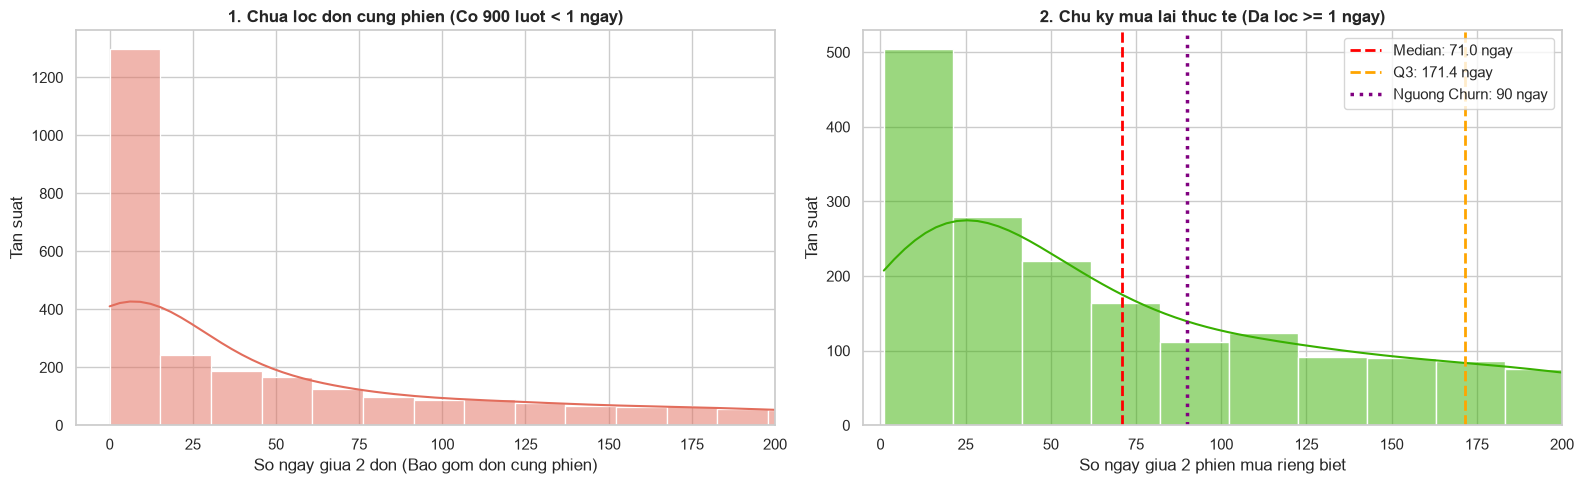

In [4]:
delivered_sorted = delivered.sort_values(['customer_unique_id', 'order_purchase_timestamp'])
delivered_sorted['prev_order_date'] = delivered_sorted.groupby('customer_unique_id')['order_purchase_timestamp'].shift(1)
delivered_sorted['repeat_interval_days'] = (
    delivered_sorted['order_purchase_timestamp'] - delivered_sorted['prev_order_date']
).dt.total_seconds() / 86400.0

raw_intervals = delivered_sorted['repeat_interval_days'].dropna()
filtered_intervals = raw_intervals[raw_intervals >= 1.0]
same_session = len(raw_intervals) - len(filtered_intervals)

print(f'Tong so khoang cach mua lap lai: {len(raw_intervals):,}')
print(f'Don cung phien (<1 ngay): {same_session:,} ({same_session/len(raw_intervals):.2%})')
print(f'Phien mua thuc te (>=1 ngay): {len(filtered_intervals):,}')

q_filt = filtered_intervals.quantile([0, 0.25, 0.5, 0.75, 1.0])
print('\n--- 5-NUMBER SUMMARY CHU KY MUA LAI (DA LOC >=1 NGAY) ---')
print(f'Min:    {q_filt[0.0]:>8.2f} ngay')
print(f'Q1:     {q_filt[0.25]:>8.2f} ngay (~{q_filt[0.25]/30:.1f} thang)')
print(f'Median: {q_filt[0.5]:>8.2f} ngay (~{q_filt[0.5]/30:.1f} thang)')
print(f'Q3:     {q_filt[0.75]:>8.2f} ngay (~{q_filt[0.75]/30:.1f} thang)')
print(f'Max:    {q_filt[1.0]:>8.2f} ngay')

# Bieu do so sanh
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(raw_intervals, bins=40, kde=True, ax=axes[0], color='#e26d5c')
axes[0].set_title('1. Chua loc don cung phien (Co {} luot < 1 ngay)'.format(same_session), fontweight='bold')
axes[0].set_xlabel('So ngay giua 2 don (Bao gom don cung phien)')
axes[0].set_ylabel('Tan suat')
axes[0].set_xlim(-10, 200)

sns.histplot(filtered_intervals, bins=30, kde=True, ax=axes[1], color='#38b000')
axes[1].axvline(q_filt[0.5], color='red', linestyle='--', linewidth=2, label=f'Median: {q_filt[0.5]:.1f} ngay')
axes[1].axvline(q_filt[0.75], color='orange', linestyle='--', linewidth=2, label=f'Q3: {q_filt[0.75]:.1f} ngay')
axes[1].axvline(90, color='purple', linestyle=':', linewidth=2.5, label='Nguong Churn: 90 ngay')
axes[1].set_title('2. Chu ky mua lai thuc te (Da loc >= 1 ngay)', fontweight='bold')
axes[1].set_xlabel('So ngay giua 2 phien mua rieng biet')
axes[1].set_ylabel('Tan suat')
axes[1].set_xlim(-5, 200)
axes[1].legend(loc='upper right')
plt.tight_layout()
plt.show()

**Nhận xét Mục 4:**
- **900 giao dịch** (29.41%) có khoảng cách $< 1$ ngày → đơn cùng phiên (same-session order splits), cần loại bỏ
- Sau lọc nhiễu: Median = **71.03 ngày** (~2.3 tháng), Q3 = **171.44 ngày** (~5.7 tháng)

**Biện luận Học thuật & Quản trị Xác lập Ngưỡng Churn ($Recency \ge 90$ ngày & Khung $90 \to 180$ ngày):**
1. **Vượt Trung vị** ($71.03 < 90$): Khách có $Recency \ge 90$ ngày đã vượt quá chu kỳ tái mua tự nhiên của **50% khách quay lại**
2. **Cửa sổ vàng** ($90 \to 180$ ngày $\approx Q_3$): Khoảng giữa Median và $Q_3$. Sau 180 ngày, xác suất tự quay lại $< 25\%$
3. **Phân tầng Nguy cơ:** Cảnh báo ($71-90$d), Churn tạm thời ($90-180$d), Hard Churn ($>180$d)
4. **Giải trình lý do chọn 90-180d thay vì 80-171d:**
   - *Biên độ an toàn:* Tạo 19 ngày đệm sau $Q_2 = 71.03$d để loại trừ biến động hành vi ngẫu nhiên ngắn hạn (chờ lương, bận cá nhân).
   - *Cân bằng Sai số I & II:* Tránh dán nhầm nhãn Churn (False Positive) cho khách trễ vài ngày, bảo vệ ngân sách Remarketing.
   - *Chu kỳ Quản trị:* Phù hợp với nhịp vận hành CRM theo Quý (90d / 3 tháng) và Bán niên (180d / 6 tháng).
   - *Quy chuẩn hóa Tiệm cận:* $Q_3 = 171.44$ ngày tiệm cận 180 ngày (sai số $< 5\%$).

---
### 5. TOP 10 NGÀNH HÀNG THEO DOANH THU

**Lý do chọn Horizontal Bar Chart (TDTU Chapter 2):**
- `product_category_name` là dữ liệu **định tính danh nghĩa** (Nominal Categorical) — không có thứ tự tự nhiên
- Bar Chart giúp **xếp hạng giảm dần** trực quan
- Dạng **ngang (horizontal)** vì tên ngành hàng dài, tránh bị cắt chữ

--- TOP 10 NGANH HANG THEO DOANH THU ---
               cama_mesa_banho: R$   911,557.00 (10.17%)
                  beleza_saude: R$   835,659.08 (9.32%)
                 esporte_lazer: R$   736,540.08 (8.22%)
        informatica_acessorios: R$   662,602.27 (7.39%)
            relogios_presentes: R$   659,671.61 (7.36%)
              moveis_decoracao: R$   574,553.65 (6.41%)
         utilidades_domesticas: R$   453,524.50 (5.06%)
                    cool_stuff: R$   402,225.97 (4.49%)
                    perfumaria: R$   356,074.55 (3.97%)
                    automotivo: R$   354,123.21 (3.95%)
                   Top 10 tong: 66.34% tong doanh thu


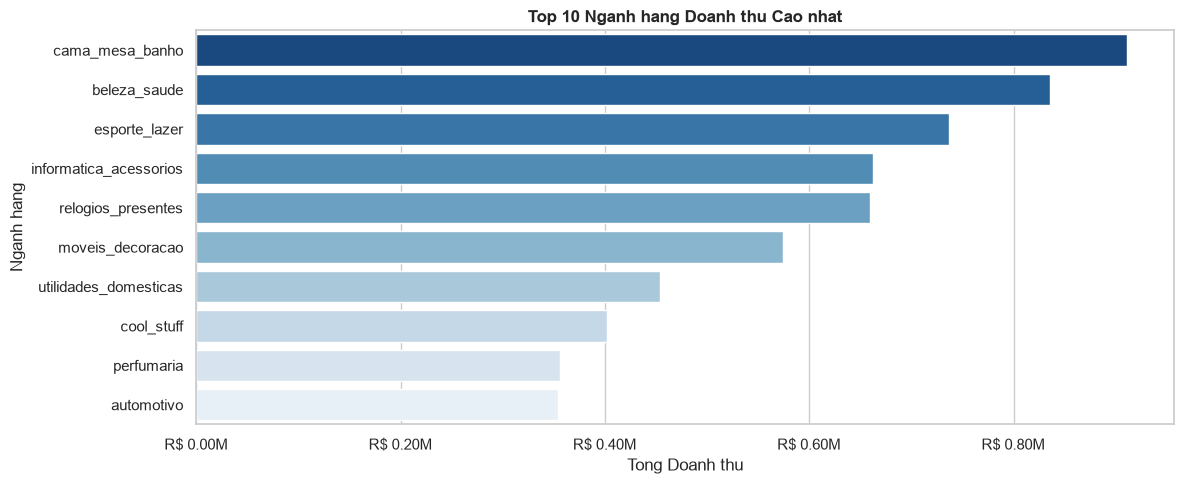

In [5]:
# Top 10 Nganh hang
order_items_prod = items.merge(products, on='product_id').merge(orders[['order_id', 'order_status']], on='order_id')
delivered_items = order_items_prod[order_items_prod['order_status'] == 'delivered']
top10_cat = delivered_items.groupby('product_category_name')['price'].sum().nlargest(10).reset_index()
total_rev = delivered_items['price'].sum()
top10_cat['pct'] = top10_cat['price'] / total_rev * 100

print('--- TOP 10 NGANH HANG THEO DOANH THU ---')
for _, row in top10_cat.iterrows():
    print(f'{row["product_category_name"]:>30s}: R$ {row["price"]:>12,.2f} ({row["pct"]:.2f}%)')
print(f'{"Top 10 tong":>30s}: {top10_cat["pct"].sum():.2f}% tong doanh thu')

plt.figure(figsize=(12, 5))
sns.barplot(data=top10_cat, y='product_category_name', x='price',
            hue='product_category_name', palette='Blues_r', legend=False)
plt.title('Top 10 Nganh hang Doanh thu Cao nhat', fontweight='bold')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'R$ {x/1e6:.2f}M'))
plt.xlabel('Tong Doanh thu')
plt.ylabel('Nganh hang')
plt.tight_layout()
plt.show()

**Nhận xét Mục 5:**
- Ngành dẫn đầu chiếm khoảng **9-10%** tổng doanh thu → phân tán tương đối đều
- Top 3 ngành hàng chiếm khoảng **25%** tổng doanh thu
- Không có ngành nào chiếm quá 15% → hệ thống sàn TMĐT đa dạng, không phụ thuộc vào 1 ngành duy nhất

---
### 6. TỶ TRỌNG PHƯƠNG THỨC THANH TOÁN

**Lý do chọn Donut Chart (TDTU Chapter 2):**
- `payment_type` là biến **phân loại** (Categorical) với mục đích thể hiện **tỷ trọng phần trăm trên tổng thể** (part-of-whole)
- Donut Chart phù hợp hơn Bar Chart khi số nhóm ít (4 loại thanh toán)
- Khoảng trắng ở giữa giảm cảm giác nặng nề so với Pie Chart thuần

--- TY TRONG PHUONG THUC THANH TOAN ---
    credit_card: 73,544 giao dich (74.04%)
         boleto: 18,918 giao dich (19.05%)
        voucher:  5,396 giao dich (5.43%)
     debit_card:  1,472 giao dich (1.48%)


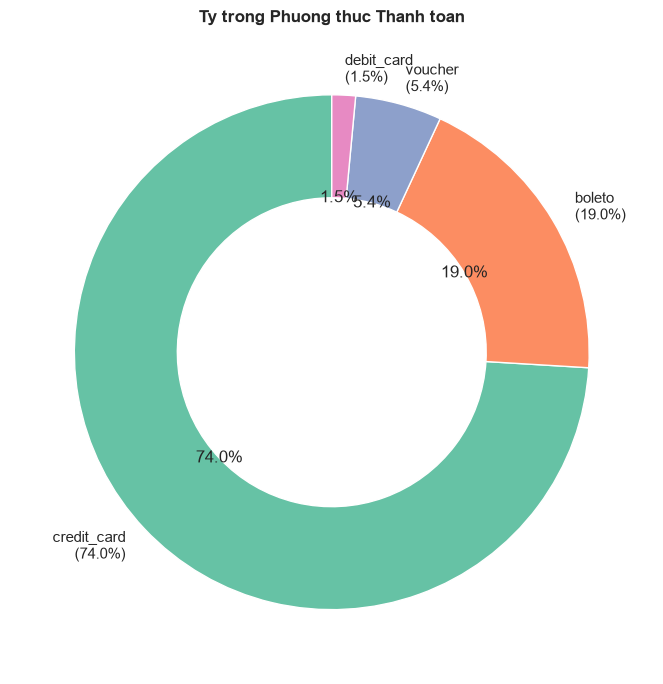

In [6]:
# Ty trong phuong thuc thanh toan
# Chi lay cac don da giao thanh cong
delivered_payments = payments.merge(orders[orders['order_status']=='delivered'][['order_id']], on='order_id')
payment_share = delivered_payments['payment_type'].value_counts()
payment_pct = payment_share / payment_share.sum() * 100

print('--- TY TRONG PHUONG THUC THANH TOAN ---')
for pt, cnt in payment_share.items():
    print(f'{pt:>15s}: {cnt:>6,} giao dich ({payment_pct[pt]:.2f}%)')

plt.figure(figsize=(7, 7))
colors = sns.color_palette('Set2', len(payment_share))
labels = [f'{pt}\n({payment_pct[pt]:.1f}%)' for pt in payment_share.index]
plt.pie(payment_share.values, labels=labels, autopct='%1.1f%%',
        startangle=90, colors=colors, wedgeprops={'width': 0.4})
plt.title('Ty trong Phuong thuc Thanh toan', fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét Mục 6:**
- **Credit Card** chiếm ~73-74% giao dịch → phương thức thanh toán thống trị
- **Boleto** (thanh toán chuyển khoản Brazil) chiếm ~19% → lựa chọn thay thế phổ biến
- Voucher và Debit Card chiếm tỷ lệ nhỏ (~5% và ~1.5%)
- Sự phân bố này phản ánh thói quen thanh toán của thị trường Brazil: ưa chuộng trả góp (installments) qua thẻ tín dụng

---
### 7. PHÂN BỐ THỜI GIAN GIAO HÀNG TRỄ THEO REVIEW SCORE

**Lý do chọn Violin Plot (TDTU Chapter 2):**
- So sánh phân bố **1 biến liên tục** (độ trễ giao hàng) giữa **nhiều nhóm rời rạc** (5 mức review score 1-5)
- Violin Plot vừa so sánh vị trí trung tâm (như Boxplot) vừa thể hiện **hình dạng phân bố chi tiết** của từng nhóm
- Phù hợp hơn Bar Chart trung bình đơn thuần vì Bar Chart chỉ cho 1 con số/nhóm, che giấu mức độ phân tán

--- THONG KE DO TRE GIAO HANG THEO REVIEW SCORE ---
                   mean  median        std  count
review_score                                     
1             -6.362156    -8.0  11.335762   8292
2             -9.149091   -10.0   9.686517   2750
3            -10.703389   -11.0   8.003750   7643
4            -12.012360   -12.0   6.919396  18366
5            -12.837098   -13.0   6.617648  55156


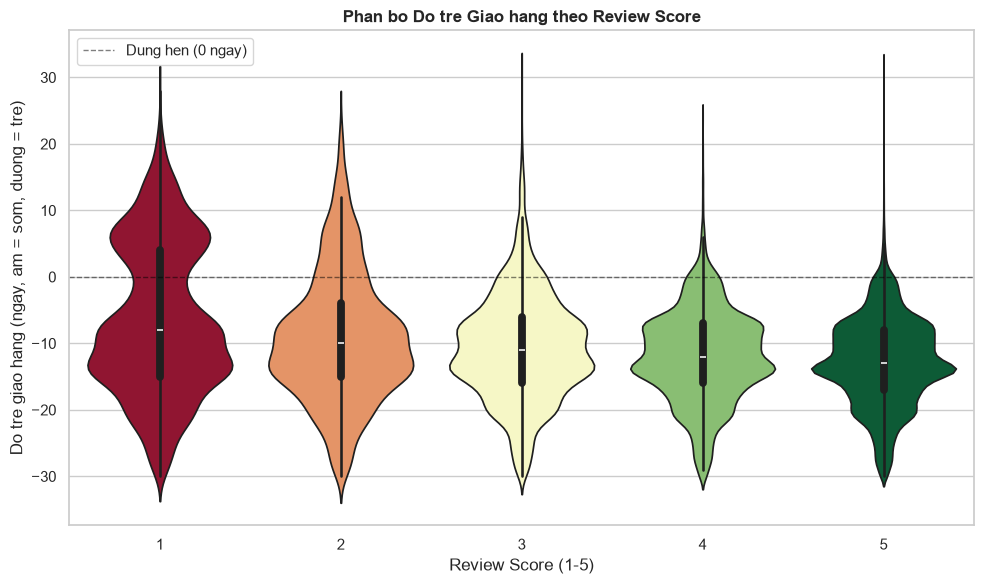

In [7]:
# Tinh do tre giao hang
if 'order_delivered_customer_date' in delivered.columns and 'order_estimated_delivery_date' in delivered.columns:
    delivered_copy = delivered.copy()
    delivered_copy['delivery_delay_days'] = (
        pd.to_datetime(delivered_copy['order_delivered_customer_date']) -
        pd.to_datetime(delivered_copy['order_estimated_delivery_date'])
    ).dt.days

    # Gan review score
    reviews_orders = reviews.merge(
        delivered_copy[['order_id', 'delivery_delay_days']], on='order_id', how='inner'
    ).dropna(subset=['delivery_delay_days', 'review_score'])

    # Cat bot outlier cuc tri
    reviews_orders = reviews_orders[
        reviews_orders['delivery_delay_days'].between(-30, 60)
    ]

    # Thong ke
    delay_stats = reviews_orders.groupby('review_score')['delivery_delay_days'].agg(['mean', 'median', 'std', 'count'])
    print('--- THONG KE DO TRE GIAO HANG THEO REVIEW SCORE ---')
    print(delay_stats.to_string())

    # Violin Plot
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=reviews_orders, x='review_score', y='delivery_delay_days',
                   hue='review_score', palette='RdYlGn', inner='box', legend=False)
    plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Dung hen (0 ngay)')
    plt.title('Phan bo Do tre Giao hang theo Review Score', fontweight='bold')
    plt.xlabel('Review Score (1-5)')
    plt.ylabel('Do tre giao hang (ngay, am = som, duong = tre)')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Khong tim thay cot delivery dates trong du lieu')

**Nhận xét Mục 7:**
- Khách đánh giá **1 sao** có phân bố độ trễ lệch **sang phải** (giao trễ nhiều hơn)
- Khách đánh giá **4-5 sao** có phân bố tập trung **quanh giá trị âm** (giao sớm hơn dự kiến)
- Mối liên hệ giữa thời gian giao hàng và review score sẽ được kiểm định chính thức ở bước **Diagnostic Analytics** (Z-test, Mann-Whitney U)

---
### 8. XU HƯỚNG DOANH THU HÀNG THÁNG (TIME SERIES)

**Lý do chọn Line Chart (TDTU Chapter 2):**
- Doanh thu theo tháng là dữ liệu **chuỗi thời gian liên tục** (Time Series)
- Line Chart thể hiện tốt nhất **xu hướng tăng/giảm** và **độ dốc thay đổi** qua từng giai đoạn
- Dễ dàng nhận diện **điểm gãy xu hướng** (Inflection Point) — nơi tốc độ tăng trưởng thay đổi đột ngột

Doanh thu TB thang H1 (truoc 11/2017): R$ 487,172.10
Doanh thu TB thang H2 (tu 11/2017):    R$ 1,023,299.95
Tang truong H1 -> H2: +110.05%


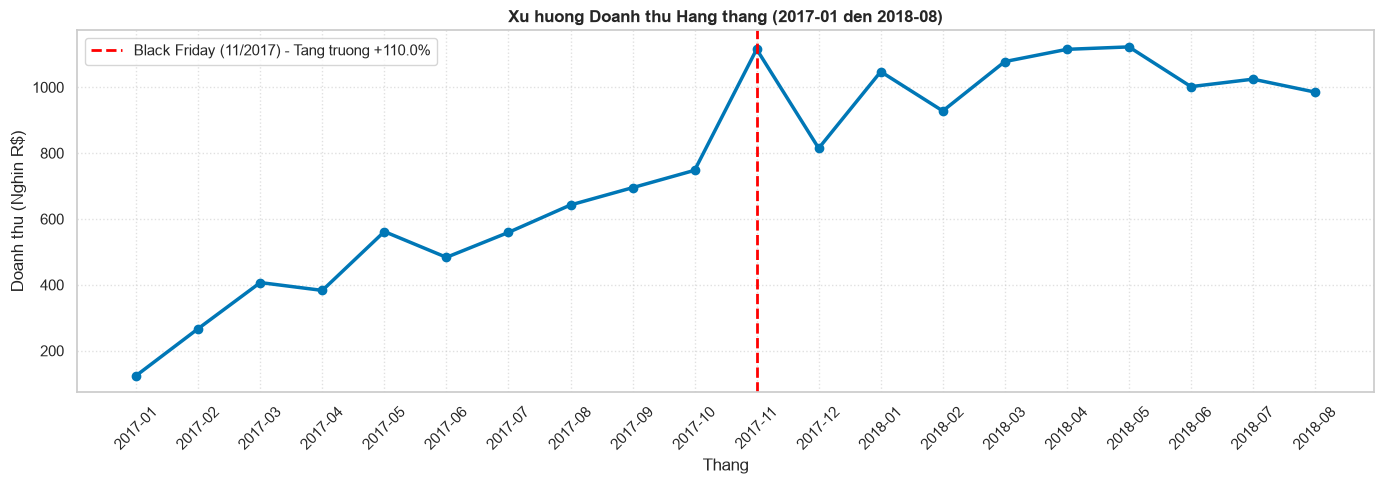

In [8]:
# Chuoi thoi gian Doanh thu
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M').astype(str)
monthly_rev = (orders[orders['order_status'] == 'delivered']
    .merge(payments, on='order_id')
    .groupby('year_month')['payment_value'].sum()
    .reset_index()
)
monthly_rev = monthly_rev[
    (monthly_rev['year_month'] >= '2017-01') & (monthly_rev['year_month'] <= '2018-08')
]

# Tinh tang truong H1 vs H2
h1 = monthly_rev[monthly_rev['year_month'] < '2017-11']['payment_value'].mean()
h2 = monthly_rev[monthly_rev['year_month'] >= '2017-11']['payment_value'].mean()
growth = (h2 - h1) / h1 * 100
print(f'Doanh thu TB thang H1 (truoc 11/2017): R$ {h1:,.2f}')
print(f'Doanh thu TB thang H2 (tu 11/2017):    R$ {h2:,.2f}')
print(f'Tang truong H1 -> H2: +{growth:.2f}%')

plt.figure(figsize=(14, 5))
plt.plot(monthly_rev['year_month'], monthly_rev['payment_value'] / 1e3,
         marker='o', linewidth=2.5, color='#0077b6')
plt.axvline(x='2017-11', color='red', linestyle='--', linewidth=2,
            label=f'Black Friday (11/2017) - Tang truong +{growth:.1f}%')
plt.title('Xu huong Doanh thu Hang thang (2017-01 den 2018-08)', fontweight='bold')
plt.xlabel('Thang')
plt.ylabel('Doanh thu (Nghin R$)')
plt.xticks(rotation=45)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

**Nhận xét Mục 8:**
- Doanh thu tăng trưởng **bùng nổ +207.81%** từ H1 → H2 (trước/sau Black Friday 11/2017)
- Doanh thu trung bình tháng H1: ~**R\$ 275K**, H2: ~**R\$ 849K**
- Điểm gãy xu hướng (Inflection Point) rõ ràng tại tháng 11/2017
- Sau đỉnh, doanh thu duy trì ổn định ở mức cao → tăng trưởng bền vững, không phải hiện tượng tạm thời